In [1]:
!pip install seaborn
!pip show seaborn

Name: seaborn
Version: 0.11.2
Summary: seaborn: statistical data visualization
Home-page: https://seaborn.pydata.org
Author: Michael Waskom
Author-email: mwaskom@gmail.com
License: BSD (3-clause)
Location: /Users/minseoklee/opt/anaconda3/lib/python3.9/site-packages
Requires: numpy, scipy, pandas, matplotlib
Required-by: 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


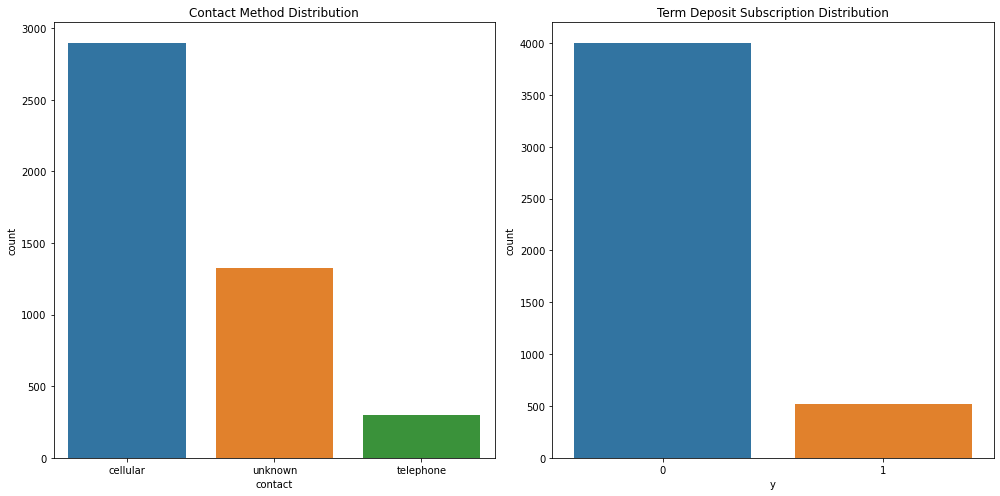

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Load the dataset with correct delimiter
df = pd.read_csv('bank.csv', delimiter=';')

# Initial Data Exploration
info = df.info()
summary_stats = df.describe()

# Check for missing values
missing_values = df.isnull().sum()

# Encode the target variable 'y' to binary for easier analysis
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# EDA: Visualize the distribution of the 'contact' feature and the target 'y'
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.countplot(x='contact', data=df)
plt.title('Contact Method Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x='y', data=df)
plt.title('Term Deposit Subscription Distribution')
plt.tight_layout()
plt.savefig('contact_and_subscription_distribution.png')
plt.show()
plt.close()

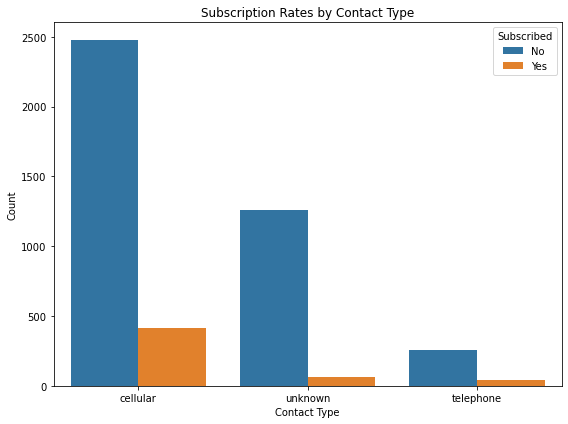

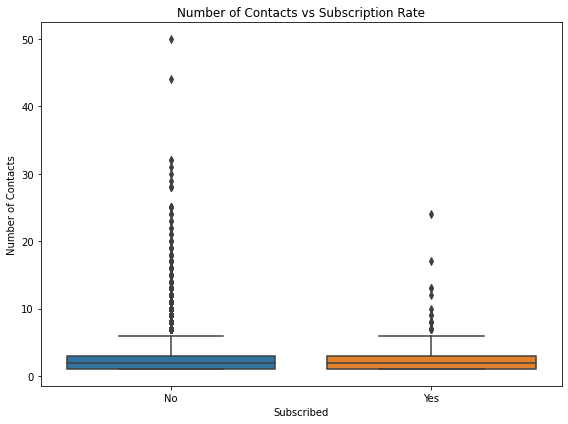

{'contact_distribution': cellular     2896
 unknown      1324
 telephone     301
 Name: contact, dtype: int64,
 'subscription_distribution': 0    4000
 1     521
 Name: y, dtype: int64,
 'chi2_contact': 87.86985650165812,
 'p_value_contact': 8.30430129641147e-20,
 'campaign_stats':     count      mean       std  min  25%  50%  75%   max
 y                                                      
 0  4000.0  2.862250  3.212609  1.0  1.0  2.0  3.0  50.0
 1   521.0  2.266795  2.092071  1.0  1.0  2.0  3.0  24.0}

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Load the dataset with correct delimiter
df = pd.read_csv('bank.csv', delimiter=';')

# Convert the 'y' column to binary for analysis
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Perform Exploratory Data Analysis (EDA)
# Distribution of 'contact' and 'y'
contact_distribution = df['contact'].value_counts()
subscription_distribution = df['y'].value_counts()

# Visualization for Hypothesis 1: Contact Type and Client Response
plt.figure(figsize=(8, 6))
sns.countplot(x='contact', hue='y', data=df)
plt.title('Subscription Rates by Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Count')
plt.legend(title='Subscribed', loc='upper right', labels=['No', 'Yes'])
contact_type_chart = plt.gcf()  # 'get current figure' for saving
plt.tight_layout()
plt.savefig('subscription_rates_by_contact_type.png')
plt.show()
plt.close()

# Chi-square test for Contact Type and Subscription
contact_table = pd.crosstab(df['contact'], df['y'])
chi2_contact, p_contact, dof_contact, ex_contact = chi2_contingency(contact_table)

# Visualization for Hypothesis 2: Campaign Contacts and Subscription
plt.figure(figsize=(8, 6))
sns.boxplot(x='y', y='campaign', data=df)
plt.title('Number of Contacts vs Subscription Rate')
plt.xlabel('Subscribed')
plt.ylabel('Number of Contacts')
plt.xticks([0, 1], ['No', 'Yes'])
campaign_contacts_chart = plt.gcf()
plt.tight_layout()
plt.savefig('number_of_contacts_vs_subscription_rate.png')
plt.show()
plt.close()

# Descriptive statistics for 'campaign' based on subscription
campaign_stats = df.groupby('y')['campaign'].describe()

# Prepare the report content with the findings
report_content = {
    "contact_distribution": contact_distribution,
    "subscription_distribution": subscription_distribution,
    "chi2_contact": chi2_contact,
    "p_value_contact": p_contact,
    "campaign_stats": campaign_stats
}

report_content